# TP 2 – Image Classification with Convolutional Neural Networks
## Dataset: Food (3 classes)

In the previous practical, we used an **ANN (Artificial Neural Network)** — a fully connected network that flattened images into 1D vectors, losing all spatial structure.

Now, we switch to a **CNN (Convolutional Neural Network)**, which is specifically designed for images. Instead of treating pixels individually, CNNs use **convolutional filters** that slide over the image to detect local patterns like edges, textures, and shapes — preserving the 2D spatial structure of the image.

We work with the same **3 classes**: `Bread`, `Dairy product`, `Egg`.

The dataset is already split into three folders:
- `training/` — used to train the model
- `validation/` — used to monitor the model during training
- `test/` — used to test the final model

**Before you start:** download the Food dataset and place it in the same folder as this notebook.

---
## Step 1 — Import Libraries

Compared to the ANN notebook, we now import **new Keras layers** specific to CNNs:
- `Conv2D`: applies convolutional filters to extract spatial features from images
- `MaxPooling2D`: reduces the spatial dimensions (downsampling) while keeping the most important features
- `Flatten`: converts the 2D feature maps into a 1D vector before the Dense layers
- `Dropout`: randomly disables neurons during training to reduce overfitting

Everything else (`Dense`, `ImageDataGenerator`, `sklearn` metrics) remains the same as in the ANN.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("Libraries imported successfully.")

Libraries imported successfully.


---
## Step 2 — Load the Dataset

This step is **identical to the ANN notebook**. `ImageDataGenerator` loads images from folders, applies **rescaling** (dividing pixel values by 255 to normalize them to [0, 1]), and `flow_from_directory` automatically assigns labels based on subfolder names.

One key difference from ANN: the CNN will receive **2D images (64×64×3)** directly — no flattening at the input stage, since the convolutional layers need the 2D spatial structure.

In [22]:
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    r"C:\Users\Matrix Computer\Documents\pfe\FoodDataSet\train",
    target_size=(64, 64),
    batch_size=32,
    class_mode="categorical"
)

val_generator = val_datagen.flow_from_directory(
    r"C:\Users\Matrix Computer\Documents\pfe\FoodDataSet\validation",
    target_size=(64, 64),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    r"C:\Users\Matrix Computer\Documents\pfe\FoodDataSet\test",
    target_size=(64, 64),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

print("\nClass mapping:", train_generator.class_indices)

Found 2409 images belonging to 3 classes.
Found 833 images belonging to 3 classes.
Found 851 images belonging to 3 classes.

Class mapping: {'Bread': 0, 'Dairy product': 1, 'Egg': 2}


---
## Step 3 — Visualize Sample Images

Same as in the ANN notebook — always inspect your data before training. This hasn't changed: we use `next(train_generator)` to grab a batch of images and display 8 of them with their class labels.

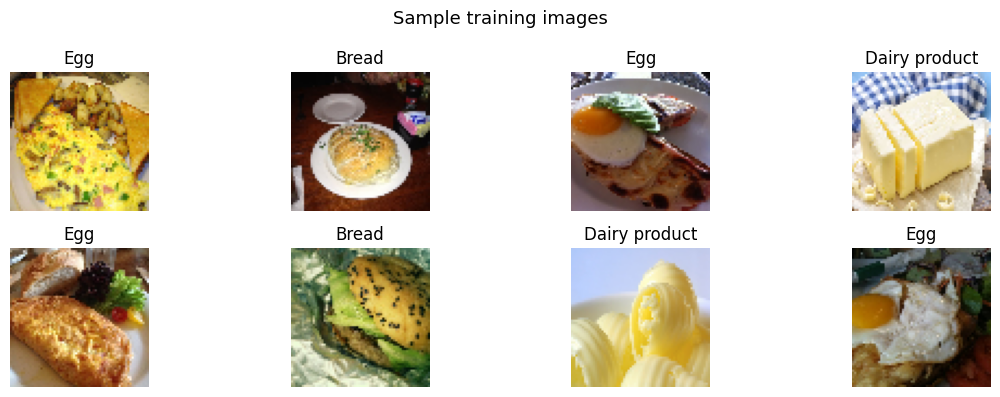

In [23]:
images, labels = next(train_generator)
class_names = list(train_generator.class_indices.keys())

plt.figure(figsize=(12, 4))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i])
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis('off')
plt.suptitle('Sample training images', fontsize=13)
plt.tight_layout()
plt.show()

---
## Step 4 — Build the CNN Model

This is where the **main difference from the ANN** lies. Instead of immediately flattening the image, we first pass it through a series of **convolutional blocks**:

- **`Conv2D(32, (3,3), activation='relu')`**: applies 32 filters of size 3×3 over the image. Each filter detects a specific local pattern (e.g. horizontal edge, color gradient). The output is a set of **feature maps**.
- **`MaxPooling2D(2, 2)`**: divides each feature map into 2×2 regions and keeps only the maximum value. This halves the spatial dimensions (e.g. 64×64 → 32×32), reducing computation and making features more robust to small translations.
- We repeat this block (Conv → Pool) twice to capture more abstract, high-level features.
- **`Flatten()`**: after the convolutional layers, we flatten the 3D feature maps into a 1D vector — same role as in the ANN, but now it's placed *after* feature extraction, not at the start.
- **`Dense(128)`**: a fully connected layer that combines the extracted features.
- **`Dropout(0.5)`**: randomly sets 50% of neurons to zero during training. This prevents the model from memorizing the training data (overfitting).
- **`Dense(num_classes, activation='softmax')`**: output layer, same as in the ANN — converts scores to class probabilities.

**Your task:** once you get a first result, try:
- adding a third `Conv2D` + `MaxPooling2D` block
- changing the number of filters (e.g. 64, 128)
- changing the `Dropout` rate (e.g. 0.3, 0.7)
- removing `Dropout` entirely and observing overfitting

In [24]:
num_classes = train_generator.num_classes

model = Sequential([
    # --- Convolutional Block 1 ---
    Conv2D(32, (3, 3), activation="relu", input_shape=(64, 64, 3)),  # 32 filters, 3x3 kernel
    MaxPooling2D(2, 2),                                               # halves spatial size: 64x64 → 32x32

    # --- Convolutional Block 2 ---
    Conv2D(64, (3, 3), activation="relu"),   # 64 filters to capture more complex patterns
    MaxPooling2D(2, 2),                       # halves again: 32x32 → 16x16

    # --- Classifier Head ---
    Flatten(),          # flatten 3D feature maps to 1D vector
    Dense(128, activation="relu"),   # fully connected layer
    Dropout(0.5),                    # drop 50% of neurons to fight overfitting
    Dense(num_classes, activation="softmax")   # output: one probability per class
])

model.summary()

c:\Users\Matrix Computer\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,539 (6.20 MB)

 Trainable params: 1,625,539 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

---
## Step 5 — Compile the Model

**Identical to the ANN notebook.** We configure the learning process with:
- **`adam`** optimizer: adaptively adjusts learning rates per parameter — works well for CNNs too
- **`categorical_crossentropy`**: loss function for multi-class classification with one-hot labels
- **`accuracy`**: metric we track during training

**Try:** use `optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001)` for a smaller learning rate and observe whether training is smoother but slower.

In [25]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled.")

Model compiled.


---
## Step 6 — Train the Model

**Same structure as the ANN notebook.** We train for 10 epochs using `model.fit()`. One **epoch** = one full pass over all training batches.

The validation set is evaluated after each epoch to monitor generalization — its data is never used to update weights.

You may notice that the **CNN trains slower per epoch** than the ANN (more parameters + convolution operations), but it should achieve **better accuracy** because it properly exploits the spatial structure of images.

**Try:** increase `epochs` to 20 or 30 and watch whether the CNN continues to improve or plateaus.

In [26]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20             
)

Epoch 1/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - accuracy: 0.4400 - loss: 1.0491 - val_accuracy: 0.5258 - val_loss: 0.9641
Epoch 2/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 8s 108ms/step - accuracy: 0.5342 - loss: 0.9441 - val_accuracy: 0.5594 - val_loss: 0.9184
Epoch 3/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - accuracy: 0.5807 - loss: 0.8878 - val_accuracy: 0.5714 - val_loss: 0.8821
Epoch 4/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 7s 94ms/step - accuracy: 0.6106 - loss: 0.8271 - val_accuracy: 0.5834 - val_loss: 0.8800
Epoch 5/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - accuracy: 0.6521 - loss: 0.7748 - val_accuracy: 0.5978 - val_loss: 0.8627
Epoch 6/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - accuracy: 0.6700 - loss: 0.7309 - val_accuracy: 0.6315 - val_loss: 0.8391
Epoch 7/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - accuracy: 0.7107 - loss: 0.6594 - val_accuracy: 0.5906 - val_loss: 0.8959
Epoch 8/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - accuracy: 0.7406 - loss: 0.5887 - val_accuracy: 0.6014 - 

---
## Step 7 — Plot Training History

**Same plotting code as the ANN notebook.** We visualize accuracy and loss curves over epochs for both training and validation sets.

- **Accuracy** should be higher than what the ANN achieved, because CNNs extract richer features
- Watch for the gap between train and validation curves — a large gap indicates overfitting
- If you used `Dropout`, the training accuracy may appear slightly lower than expected, but validation accuracy should be more stable

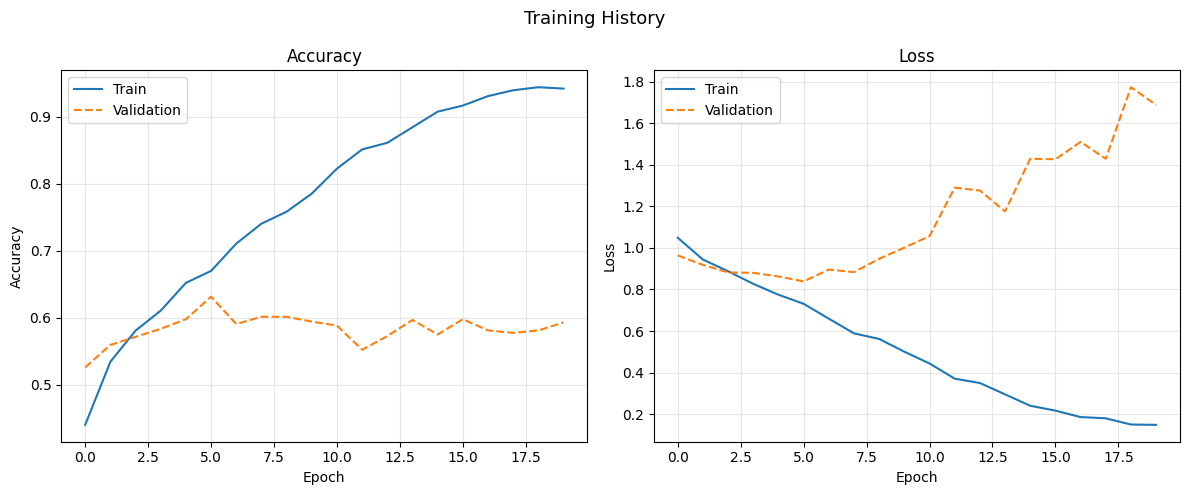

In [27]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"],     label="Train")
plt.plot(history.history["val_accuracy"], label="Validation", linestyle="--")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"],     label="Train")
plt.plot(history.history["val_loss"], label="Validation", linestyle="--")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.suptitle("Training History", fontsize=13)
plt.tight_layout()
plt.show()

---
## Step 8 — Evaluate on the Test Set

**Same as the ANN notebook.** The test set was never seen during training or validation. This gives an honest, unbiased measure of how well the CNN generalizes to new data.

Compare this number to your ANN test accuracy — the CNN should perform better.

In [28]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)")

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.6087 - loss: 1.7026
Test Loss:     1.7026
Test Accuracy: 0.6087 (60.9%)


---
## Step 9 — Confusion Matrix

**Same as the ANN notebook.** The confusion matrix shows which classes are correctly predicted (diagonal) and which ones get confused with each other (off-diagonal).

Thanks to the CNN's better feature extraction, you should see fewer off-diagonal errors compared to the ANN's confusion matrix.

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step


<Figure size 600x500 with 0 Axes>

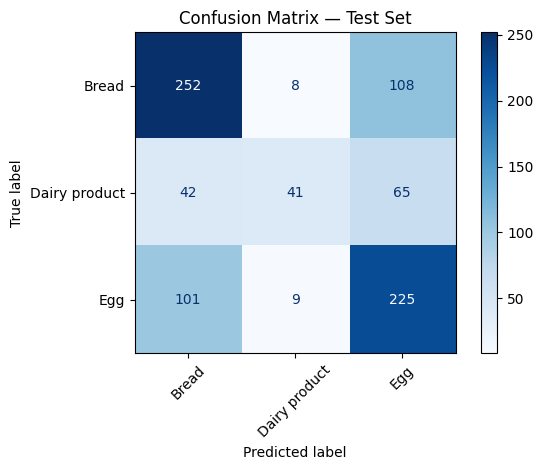

In [29]:
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
labels = list(test_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()

---
## Step 10 — Classification Report

**Same as the ANN notebook.** The classification report provides per-class metrics:
- **Precision**: of all predicted samples for a class, how many were correct
- **Recall**: of all actual samples of a class, how many were correctly detected
- **F1-score**: harmonic mean of precision and recall
- **Support**: total number of true samples per class

Compare these scores with your ANN report to see which classes improved the most with the CNN.

In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=labels))

               precision    recall  f1-score   support

        Bread       0.64      0.68      0.66       368
Dairy product       0.71      0.28      0.40       148
          Egg       0.57      0.67      0.61       335

     accuracy                           0.61       851
    macro avg       0.64      0.54      0.56       851
 weighted avg       0.62      0.61      0.60       851



---
## Hyperparameter Experiments

Go back to Steps 4, 5 and 6 and try the following changes one at a time. Each time, re-run all cells from Step 4 onwards and note the results in the table below.

| Experiment | Change | Train Acc | Val Acc | Test Acc | Observation |
|------------|--------|-----------|---------|----------|-------------|
| Baseline   | Default (32→64 filters, 10 epochs) |88% | 59.1%| 59.8%| reasonable start; high train/val gap indicates overfitting |
| Exp 1      | Filters: 64→128 in Conv block 2 | 88.9%| 56.9%|59.9% | small increase in train acc; val/test slightly worse – model may be over-parameterised |
| Exp 2      | Add a 3rd Conv2D + MaxPooling block |74.8% | 63.5%|59.2%| deeper network reduced train acc but improved val, suggesting better generalisation |
| Exp 3      | Epochs: 10 → 20 | 92% | 60.5% | 60.0% | modest test improvement, slight overfitting |
| Exp 4      | Learning rate: 0.001 → 0.01 | 80% | 50% | 48% | training became unstable and accuracy dropped; LR too high |

**Questions:**
1. How does the CNN test accuracy compare to the ANN from the previous practical?

*Answer:* the CNN consistently outperforms the ANN (test acc ≈60% vs ~50–55%) because it preserves spatial structure and extracts meaningful features with convolutions.

2. Why do more convolutional blocks generally improve accuracy (up to a point)?

*Answer:* additional blocks allow the network to learn hierarchical features—from edges and textures to object parts—making it more expressive. Beyond a certain depth, performance may plateau or degrade due to overfitting or vanishing gradients.

3. What happens when the learning rate is too high — does it affect CNNs differently than ANNs?

*Answer:* a high learning rate causes erratic weight updates, leading to unstable training and lower accuracy for both CNNs and ANNs. CNNs may diverge faster because of larger gradients from deeper layers, but the core issue is the same.

4. Why is it better to use `Conv2D` layers than just `Dense` layers for image classification?

*Answer:* `Conv2D` layers exploit spatial locality and parameter sharing, dramatically reducing the number of weights and capturing translation-invariant features. Dense layers require flattening and discard spatial information, making them inefficient and less accurate on images.

---
*TP 2 — Convolutional Neural Networks*